In [1]:
# Importing the libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Peek into the data by creating pandas dataframe
star_df = pd.read_csv('data/cleaned_star_data.csv')
star_df.sample(10) # Random 10 samples from star_df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
118,6850,229000.00000,1467.00000,-10.07,5,Red,G
147,14732,0.00011,0.00892,12.89,2,White,F
175,3614,145000.00000,1553.00000,-7.71,5,Red,M
164,8927,239000.00000,35.00000,-7.34,4,Blue,O
48,3625,184000.00000,84.00000,-6.74,4,Red,M
46,3575,123000.00000,45.00000,-6.78,4,Red,M
176,18000,200000.00000,1045.00000,-8.30,5,Blue,O
31,30000,28840.00000,6.30000,-4.20,3,Blue-White,B
60,3341,0.00560,0.05700,16.23,0,Red,M
192,2994,0.00720,0.28000,13.45,1,Red,M


In [3]:
# Check general information about the dataframe
star_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


### Observations
**1)** Dataset consists of 240 rows, 6 feature and 1 target columns,
- *Absolute Temperature (in K)*    
- *Relative Luminosity (L/Lo)*
- *Relative Radius (R/Ro)*
- *Absolute Magnitude (Mv)*
- *Star Color*
- *Spectral Class*
- *Star Type (Target classes)*
    
Here,
- *Lo = 3.828 x 10^26 Watts (Avg Luminosity of Sun)*
- *Ro = 6.9551 x 10^8 m (Avg Radius of Sun)*
    
**2)** Two categorical features (object type) which will need some kind of encoding,
- *Star Color*
- *Spectral Class*

**3)** It consists of some different features of stars. Information on the star type is given below,       
- **0** → Brown Dwarf       
- **1** → Red Dwarf       
- **2** → White Dwarf      
- **3** → Main Sequence    
- **4** → Supergiants      
- **5** → Hypergiants      

In [4]:
# Create a directory to save the visualizations
folder_name = 'star_plots'                     # directory name
os.makedirs(folder_name, exist_ok=True)        # Create directory if not existing
base_dir = f'./{folder_name}/'                 # Store the path of this directory as base_dir to use it further
print(base_dir)

./star_plots/


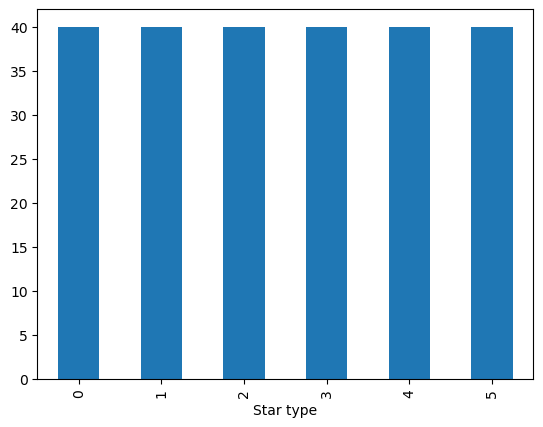

In [5]:
# Bar chart to visualize the count of stars with respective type
star_df['Star type'].value_counts().plot(kind='bar')
plt.show()

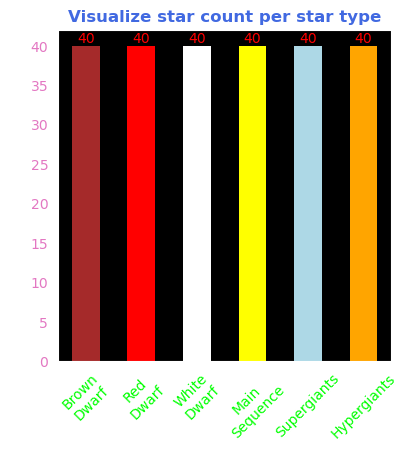

In [6]:
# Customize the plot
plt.figure(figsize=(4.3,4.3))
plt.style.use('dark_background')
ax = star_df['Star type'].value_counts().plot(kind='bar', color=['brown', 'red', 'white', 'yellow', 'lightblue', 'orange'])
ax.bar_label(ax.containers[0], color='red')
plt.title('Visualize star count per star type', color='royalblue', weight='bold')
plt.yticks(color='tab:pink')
plt.ylabel('# of Stars', color='white', fontsize=11)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5],
           labels=['Brown\nDwarf', 'Red\nDwarf', 'White\nDwarf', 'Main\nSequence', 'Supergiants', 'Hypergiants'],
           rotation=45, color='lime')

plt.savefig(base_dir+'barplot_star_count.png')
plt.show()

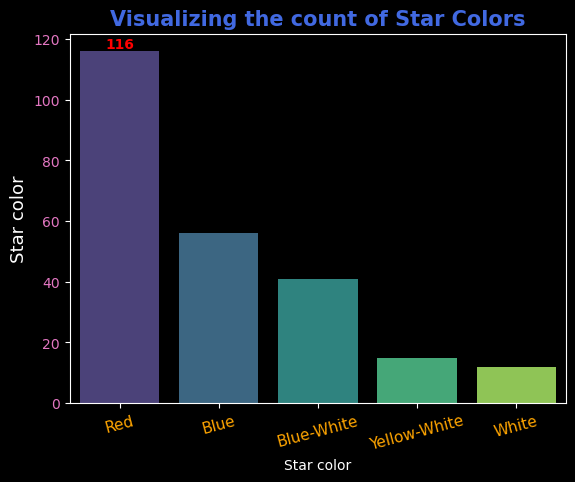

In [7]:
# Visualizing the Star color data
ax = sns.barplot(x=star_df['Star color'].value_counts().index,
            y=star_df['Star color'].value_counts(),
            palette='viridis', hue=star_df['Star color'].value_counts().index, legend=False)
ax.bar_label(ax.containers[0], color='red', weight='bold')

plt.title('Visualizing the count of Star Colors', color='royalblue', fontsize=15, weight='bold')
plt.xticks(rotation=15, color='orange', fontsize=11)
plt.ylabel('Star color',color='white', fontsize=13)
plt.yticks(color='tab:pink')
plt.savefig(base_dir+'star_colors_viz.png')
plt.show()

In [8]:
print(star_df['Star color'].value_counts())

Star color
Red             116
Blue             56
Blue-White       41
Yellow-White     15
White            12
Name: count, dtype: int64


In [9]:
# Get a gist of the data again by checking the top 5 rows of the data
star_df.head(5)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


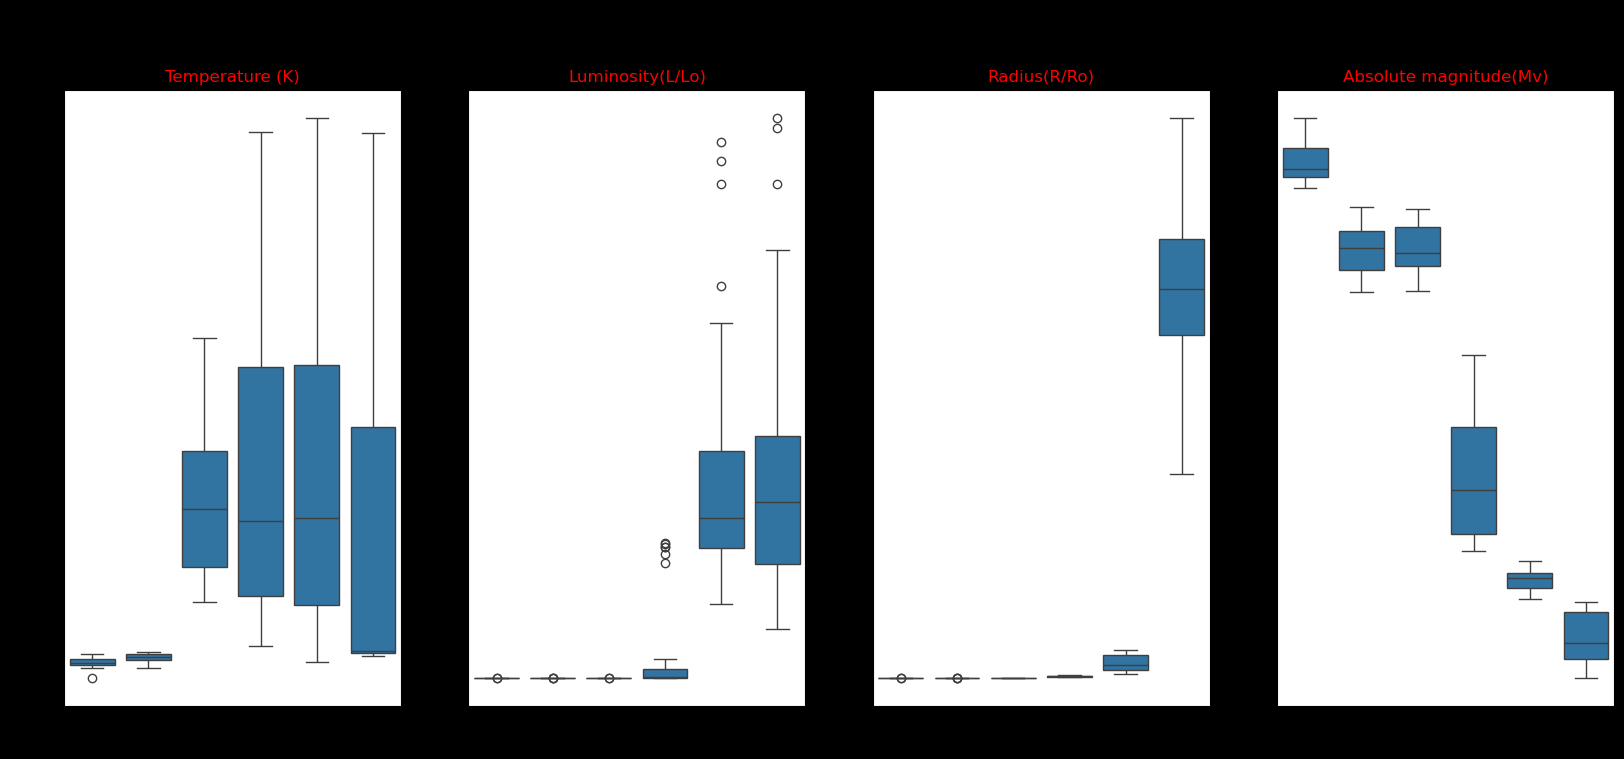

In [10]:
# Visualize Outliers in the Data
plt.figure(figsize=(20,8))
plt.style.use('default')
plt.suptitle('Visualizing the outliers in Numeric features of Star Type',
             color='black', weight='bold', fontsize=15)

# Using for loop to easily repeat some steps to create subplot
for i in range(4):
  plt.subplot(1, 4, i+1)
  sns.boxplot(x=star_df['Star type'], y=star_df.iloc[:, i])
  plt.title(star_df.columns[i], color='red')
  plt.ylabel('')

# Saving the figure
plt.savefig(base_dir+'boxplot_star_type.png')

**0** → Brown Dwarf      
**1** → Red Dwarf       
**2** → White Dwarf       
**3** → Main Sequence      
**4** → Supergiants      
**5** → Hypergiants

In [11]:
def line_subplot(star_df, colors, i):
  """
  This will create subplot within for loop

  Parameters
  ----------
  - star_df: data frame
  - colors: colors to display on plot
  - i: index of the iteration

  Generates
  ------
  - subplot on all axes with respective plots and titles
  """
  plt.subplot(4, 1, i+1)
  plt.plot(star_df.iloc[:,i], color=colors[i])
  plt.title(star_df.columns[i], color='red')

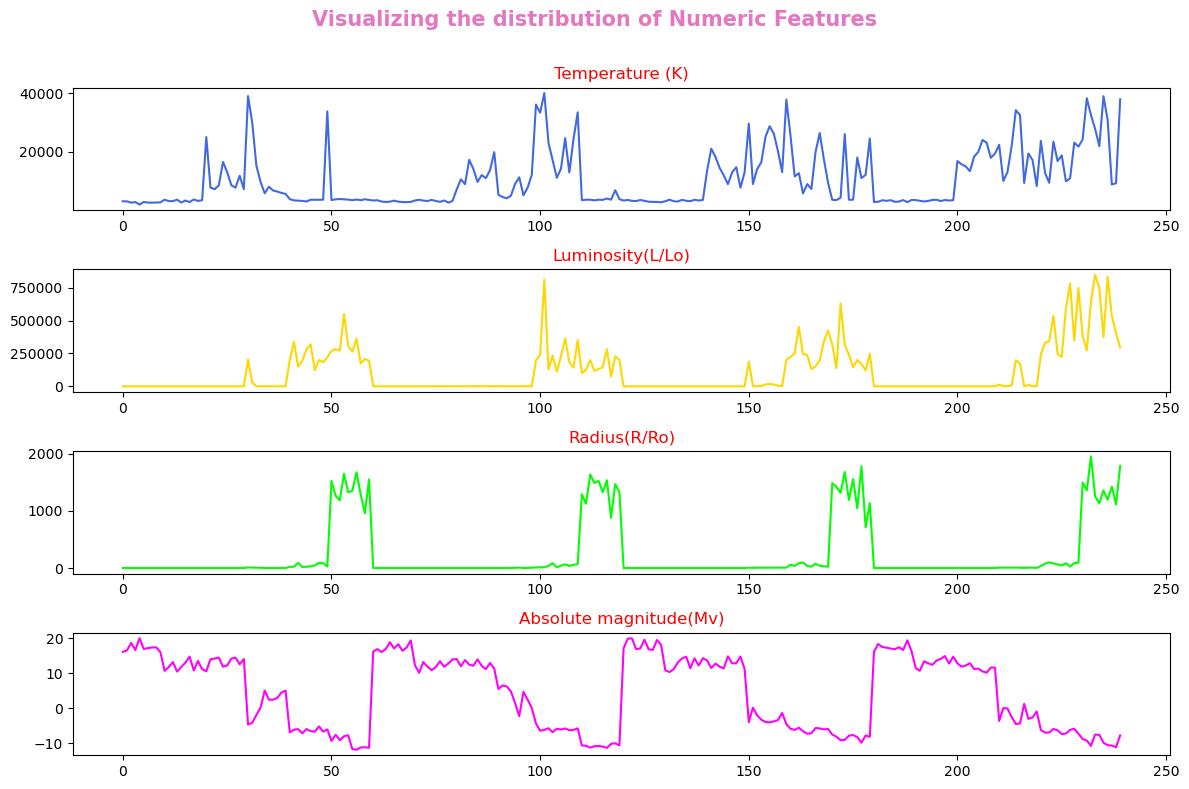

In [12]:
# Line Plots

# Colors to add in line plots
colors = ['royalblue', 'gold', 'lime', 'magenta']

# Add figure size and title to subplot
plt.figure(figsize=(12,8))
plt.suptitle('Visualizing the distribution of Numeric Features\n',
             color='tab:pink', fontsize=15, weight='bold')

# Use for loop and the function that creates subplot of line plots
for i in range(4):
  line_subplot(star_df, colors, i)

# Use tight_layout() to automatically adjust the spacing in subplot
plt.tight_layout()

# Save the figure
plt.savefig(base_dir+'line_subplot.png')
plt.show()

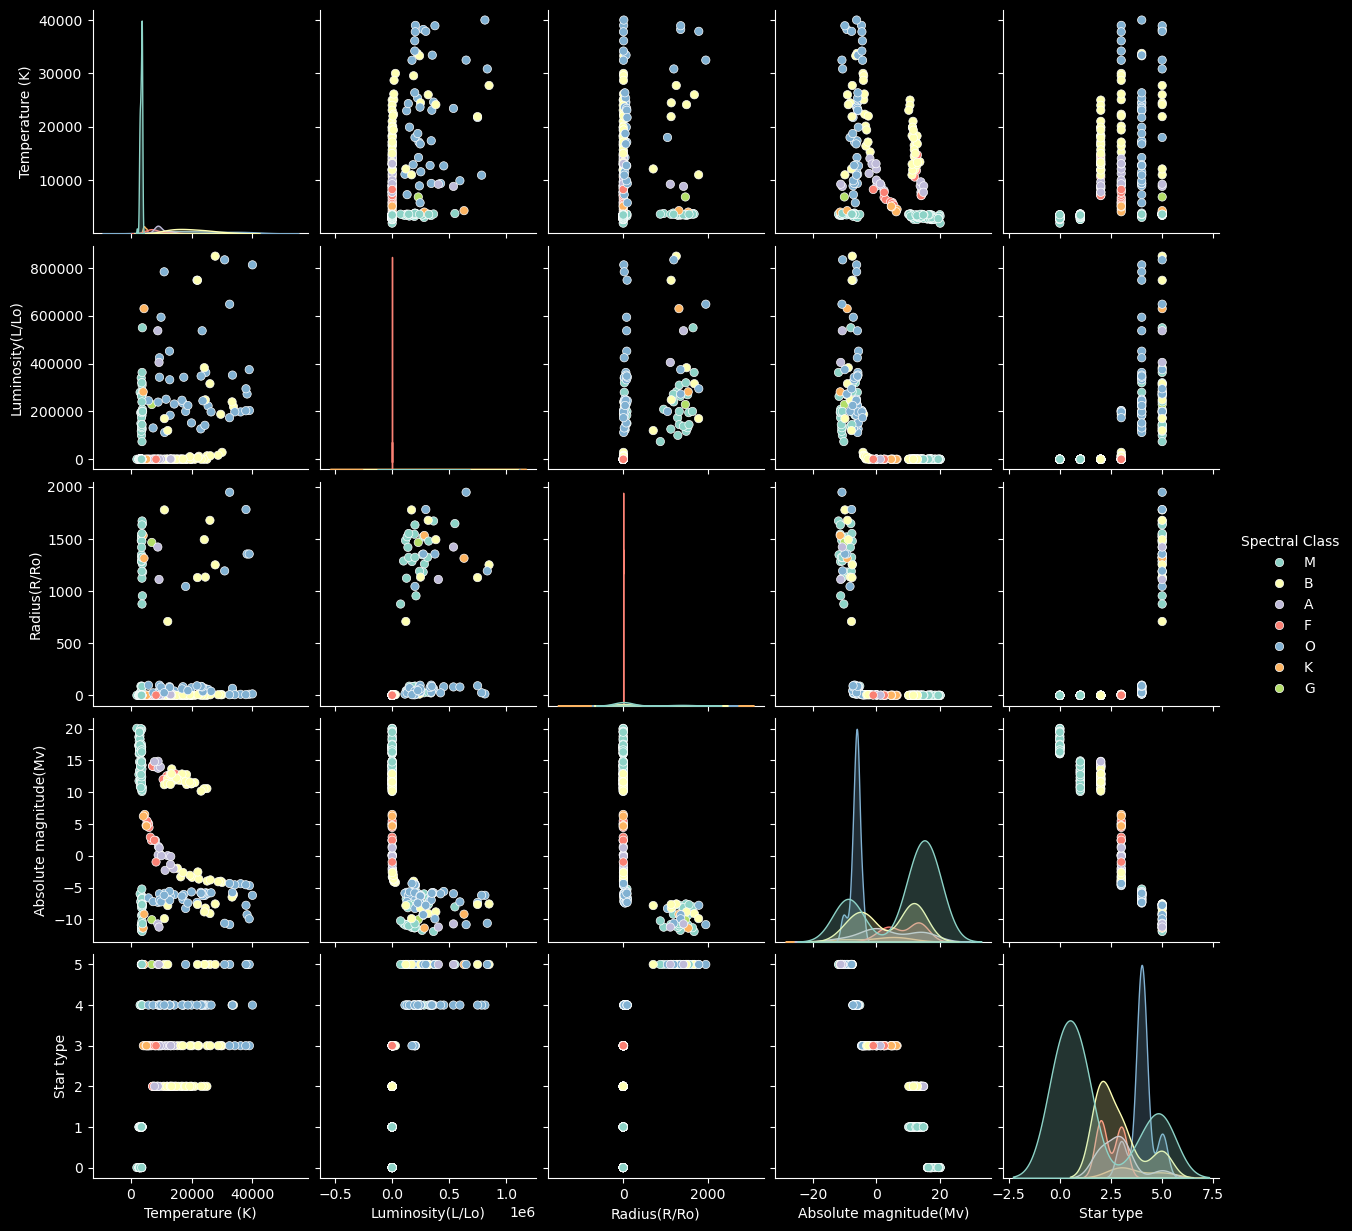

In [13]:
# Get a pairplot - scatter
plt.style.use('dark_background')
sns.pairplot(star_df, hue='Spectral Class')
plt.savefig(base_dir+'pairplot.png')
plt.show()


## Create a scatter plot of HR diagram

In [14]:
# Arrays to be used in the for loop
star_type = star_df['Star type'].values
temperature = star_df['Temperature (K)'].values
abs_mag = star_df['Absolute magnitude(Mv)'].values

# Python dictionaries --> Made of key value pairs --> To be used to get properties of star_type
star_types = {
    0: {'label': 'Brown Dwarf', 'color': 'brown', 'size': 30, 'marker': '.'},
    1: {'label': 'Red Dwarf', 'color': 'red', 'size': 35, 'marker': '.'},
    2: {'label': 'White Dwarf', 'color': 'white', 'size': 40, 'marker': '.'},
    3: {'label': 'Main Sequence', 'color': 'cyan', 'size': 30, 'marker': 'o'},
    4: {'label': 'Supergiants', 'color': 'orange', 'size': 100, 'marker': 'o'},
    5: {'label': 'Hypergiants', 'color': 'maroon', 'size': 150, 'marker': 'o'}
}

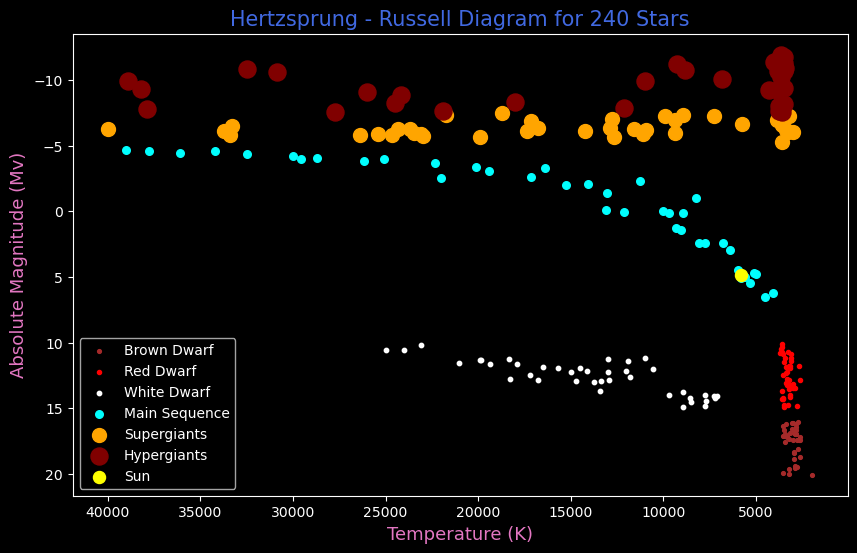

In [15]:
# Plotting a HR Diagram for Temp vs Abs mag

# Empty list and set to store ax and label of star_type
axes = []
labels = set()

plt.figure(figsize=(10, 6))

# For each and every star in the data
for i in range(len(star_type)):

  # Get its properties with its star_type from python dictionary
  properties = star_types[star_type[i]]

  # if label is not present in set labels
  if properties['label'] not in labels:
    # Then create the axis
    ax = plt.scatter(temperature[i], abs_mag[i],
                    s=properties['size'],
                    c=properties['color'],
                    marker=properties['marker'],
                    label=properties['label'])
    # Add it to axes list
    axes.append(ax)
    # Also add label to the labels set
    labels.add(properties['label'])
  # Else if the label already exist
  else:
    # Then don't save the axes nor add the label to labels set
    plt.scatter(temperature[i], abs_mag[i],
                s=properties['size'],
                c=properties['color'],
                marker=properties['marker'],
                label=properties['label'])

# Adding data for sun
ax_sun = plt.scatter(5778, 4.83, s=75, c="yellow", marker='o', label="Sun")
axes.append(ax_sun)
labels.add("Sun")

# Add title
plt.title(f"Hertzsprung - Russell Diagram for {len(star_type)} Stars", fontsize=15, color='royalblue')

# Add labels
plt.ylabel("Absolute Magnitude (Mv)", fontsize=13, color='tab:pink')
plt.xlabel("Temperature (K)", fontsize=13, color='tab:pink')

# Visualize the labels only for the axes handles
plt.legend(handles=axes)

# Invert the axes
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

# Save Figure
plt.savefig(base_dir+'hr_diagram.png')
plt.show()

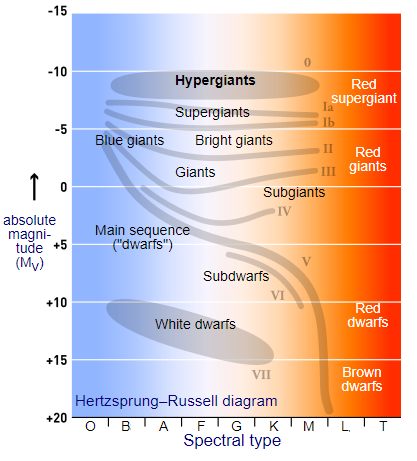

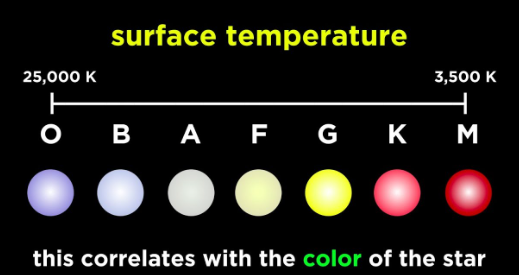

### HR diagram
<img src = 'https://www.space.fm/astronomy/images/diagrams/hr.jpg'>